# Societal Insight Mapping

In [37]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os
import glob

# Load and concatenate data
def load_and_concatenate(path_or_pattern):
    # If a directory is provided, list CSV files inside it; otherwise treat as glob pattern
    if os.path.isdir(path_or_pattern):
        files = [os.path.join(path_or_pattern, f) for f in os.listdir(path_or_pattern) if f.endswith('.csv')]
    else:
        files = glob.glob(path_or_pattern)
    if not files:
        raise FileNotFoundError(f"No CSV files found matching: {path_or_pattern}")
    df_list = [pd.read_csv(file) for file in files]
    return pd.concat(df_list, ignore_index=True)

# Only load if not already defined to avoid overwriting existing DataFrames
if 'enrolment_df' not in globals():
    enrolment_df = load_and_concatenate('api_data_aadhar_enrolment/api_data_aadhar_enrolment_*/*.csv')
if 'demographic_df' not in globals():
    demographic_df = load_and_concatenate('api_data_aadhar_demographic/api_data_aadhar_demographic_*/*.csv')
if 'biometric_df' not in globals():
    biometric_df = load_and_concatenate('api_data_aadhar_biometric/api_data_aadhar_biometric_*/*.csv')

print("Enrolment Data Shape:", enrolment_df.shape)
print("Demographic Data Shape:", demographic_df.shape)
print("Biometric Data Shape:", biometric_df.shape)

Enrolment Data Shape: (1006029, 7)
Demographic Data Shape: (2071700, 6)
Biometric Data Shape: (1861108, 6)


In [38]:
# 'Aadhaar_Number' doesn't exist in these DataFrames; merge on common keys instead
merge_keys = ['date', 'state', 'district', 'pincode']

merged_df = enrolment_df.merge(demographic_df, on=merge_keys, how='inner') \
                        .merge(biometric_df, on=merge_keys, how='inner')

# Fill missing numeric values with median
num_cols = merged_df.select_dtypes(include=np.number).columns
merged_df[num_cols] = merged_df[num_cols].apply(lambda s: s.fillna(s.median()))

print("Merged Data Shape:", merged_df.shape)
merged_df.head()


Merged Data Shape: (756586, 11)


,date,state,district,pincode,age_0_5,age_5_17,age_18_greater,demo_age_5_17,demo_age_17_,bio_age_5_17,bio_age_17_
0,01-04-2025,Punjab,Ludhiana,141007,374,110,25,206,2000,925,1404
1,01-04-2025,Punjab,Ludhiana,141007,374,110,25,206,2000,925,1404
2,01-04-2025,Madhya Pradesh,Ashok Nagar,473335,125,29,22,181,975,1418,587
3,01-04-2025,Madhya Pradesh,Ashok Nagar,473335,125,29,22,181,975,1418,587
4,01-04-2025,Jharkhand,Ranchi,834001,187,174,21,210,1855,1494,2283


## 3. Analyze Child Enrolment Delays

C:\Users\aruna\AppData\Local\Temp\ipykernel_27492\210196512.py:14: FutureWarning:



Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.




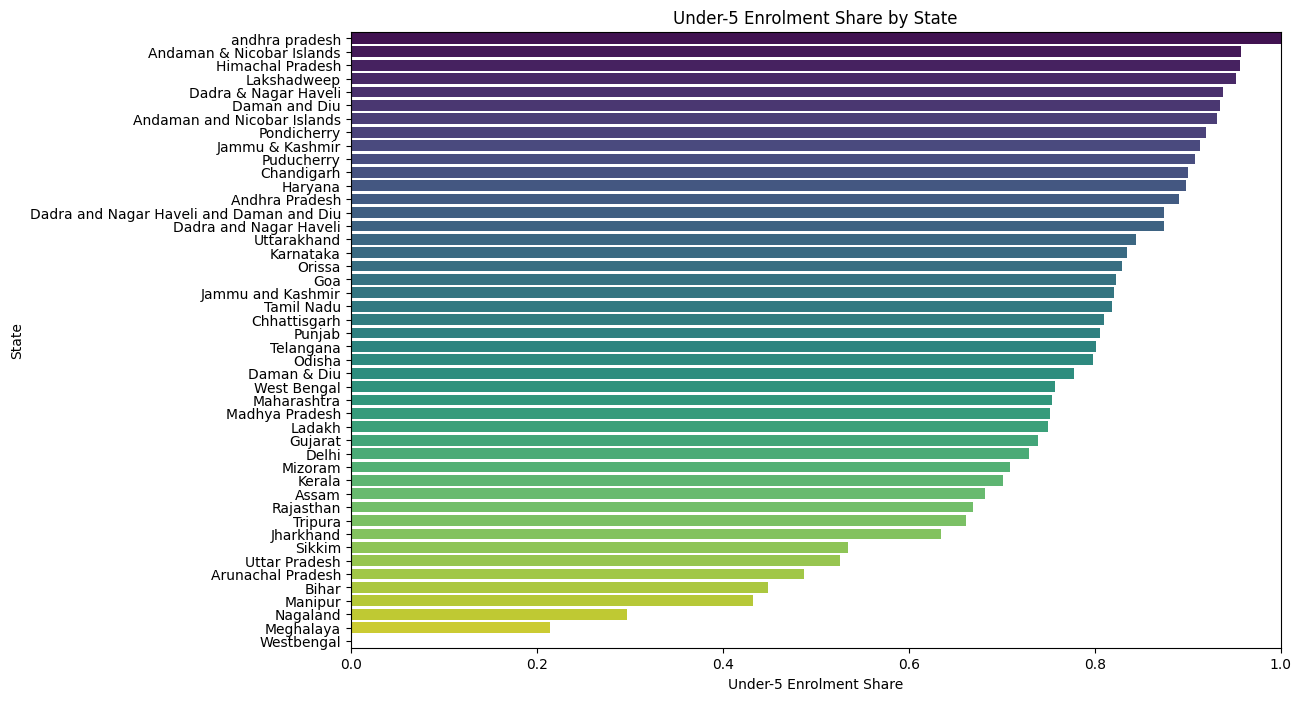

In [39]:
# There is no individual 'age' column in merged_df; use available aggregated counts.
# Compute share of under-5 enrolments by state.
child_enrolment_df = merged_df.copy()
child_enrolment_df['total_enrolment'] = child_enrolment_df[['age_0_5', 'age_5_17', 'age_18_greater']].sum(axis=1)

# Filter out rows with zero total to avoid division by zero
child_enrolment_df = child_enrolment_df[child_enrolment_df['total_enrolment'] > 0]

# Weighted child share per state = sum(age_0_5) / sum(total_enrolment)
state_totals = child_enrolment_df.groupby('state')[['age_0_5', 'total_enrolment']].sum()
child_share_by_state = (state_totals['age_0_5'] / state_totals['total_enrolment']).sort_values(ascending=False)

plt.figure(figsize=(12, 8))
sns.barplot(y=child_share_by_state.index, x=child_share_by_state.values, palette='viridis')
plt.title('Under-5 Enrolment Share by State')
plt.xlabel('Under-5 Enrolment Share')
plt.ylabel('State')
plt.xlim(0, 1)
plt.show()

## 4. Analyze Demographic Update Frequency

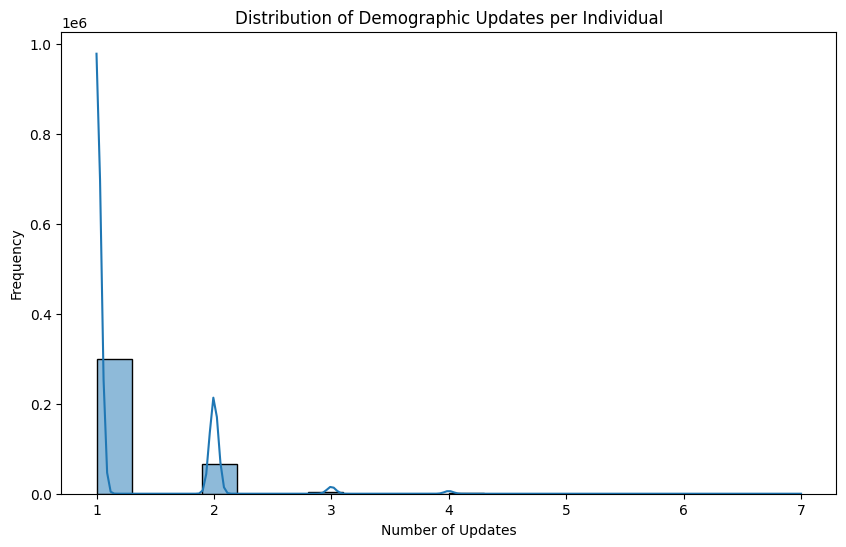

In [40]:
if 'update_type' not in merged_df.columns:
    # Simulate update types
    update_choices = ['address', 'mobile', 'name', 'None']
    merged_df['update_type'] = np.random.choice(update_choices, size=len(merged_df), p=[0.2, 0.3, 0.1, 0.4])

demographic_updates = merged_df[merged_df['update_type'] != 'None']
update_counts = demographic_updates.groupby(merge_keys).size().reset_index(name='update_count')

# Analyze distribution
plt.figure(figsize=(10, 6))
sns.histplot(update_counts['update_count'], bins=20, kde=True)
plt.title('Distribution of Demographic Updates per Individual')
plt.xlabel('Number of Updates')
plt.ylabel('Frequency')
plt.show()

# Correlate with occupation (if available)
if 'occupation' in merged_df.columns:
    updates_with_occupation = pd.merge(update_counts, merged_df[merge_keys + ['occupation']].drop_duplicates(), on=merge_keys)
    avg_updates_by_occupation = updates_with_occupation.groupby('occupation')['update_count'].mean().sort_values(ascending=False)
    
    plt.figure(figsize=(12, 8))
    sns.barplot(y=avg_updates_by_occupation.index, x=avg_updates_by_occupation.values)
    plt.title('Average Demographic Updates by Occupation')
    plt.xlabel('Average Number of Updates')
    plt.ylabel('Occupation')
    plt.show()

## 6. Analyze Rural Update Spikes

C:\Users\aruna\AppData\Local\Temp\ipykernel_27492\3411026812.py:13: FutureWarning:

'M' is deprecated and will be removed in a future version, please use 'ME' instead.



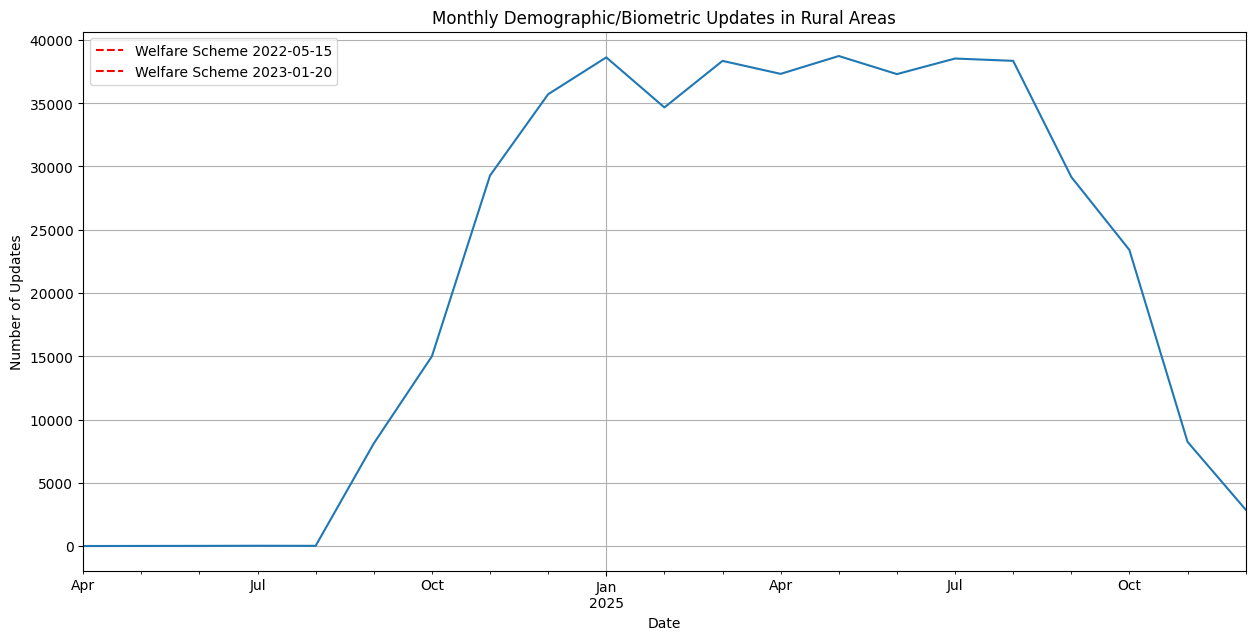

In [41]:
# Assuming 'area_type' (Rural/Urban) and 'update_date' columns exist.
# For demonstration, we'll simulate these columns.
if 'area_type' not in merged_df.columns:
    merged_df['area_type'] = np.random.choice(['Rural', 'Urban'], size=len(merged_df), p=[0.6, 0.4])
if 'update_date' not in merged_df.columns:
    # Dates are in DD-MM-YYYY format; parse explicitly to avoid month/day confusion
    merged_df['update_date'] = pd.to_datetime(merged_df['date'], format='%d-%m-%Y', errors='coerce') - pd.to_timedelta(np.random.randint(0, 365, size=len(merged_df)), unit='d')

rural_updates = merged_df[merged_df['area_type'] == 'Rural'].copy()
rural_updates.set_index('update_date', inplace=True)

# Resample to get monthly update counts
monthly_updates = rural_updates.resample('M').size()

plt.figure(figsize=(15, 7))
monthly_updates.plot(kind='line')
plt.title('Monthly Demographic/Biometric Updates in Rural Areas')
plt.xlabel('Date')
plt.ylabel('Number of Updates')
plt.grid(True)

# Example welfare scheme announcement dates
welfare_dates = [pd.to_datetime('2022-05-15'), pd.to_datetime('2023-01-20')]
for date in welfare_dates:
    plt.axvline(date, color='red', linestyle='--', label=f'Welfare Scheme {date.date()}')

plt.legend()
plt.show()

## 7. Dashboard & Output Insights

### State-wise Heatmap of Female Participation

In [ ]:
%pip install -q nbformat>=5 plotly

import plotly.express as px
import plotly.io as pio

# Prefer browser renderer unless nbformat>=4.2 is available; this avoids MIME dependency errors
try:
    nb_ok = False
    try:
        import nbformat
        # Basic version check without extra dependencies
        ver = getattr(nbformat, "__version__", "0")
        parts = ver.split(".")
        nb_ok = len(parts) >= 2 and int(parts[0]) >= 4 and int(parts[1]) >= 2
    except Exception:
        nb_ok = False

    if 'vscode' in pio.renderers and nb_ok:
        pio.renderers.default = 'vscode'
    else:
        # Use browser renderer to avoid nbformat MIME requirement
        pio.renderers.default = 'browser'
except Exception:
    # Last-resort fallback
    pio.renderers.default = 'browser'
gender_by_state_reset = child_share_by_state.rename('female_ratio').reset_index()
state_name_map = {
    'andhra pradesh': 'Andhra Pradesh',
    'Andaman and Nicobar Islands': 'Andaman & Nicobar Islands',
    'Dadra and Nagar Haveli': 'Dadra & Nagar Haveli',
    'Daman and Diu': 'Daman & Diu',
    'Pondicherry': 'Puducherry',
    'Orissa': 'Odisha',
    'Jammu and Kashmir': 'Jammu & Kashmir',
    'Westbengal': 'West Bengal',
    'Dadra and Nagar Haveli and Daman and Diu': 'Daman & Diu'
}
gender_by_state_reset['state'] = gender_by_state_reset['state'].replace(state_name_map)

# Create the heatmap
fig = px.choropleth(
    gender_by_state_reset,
    geojson="https://gist.githubusercontent.com/jbrobst/56c13bbbf9d97d187204/raw/e388c4cae20aa53cb5090210a42ebb9b765c3a66/india_states.geojson",
    featureidkey='properties.ST_NM',
    locations='state',
    color='female_ratio',
    color_continuous_scale='Reds',
    range_color=(0, 1),
    title='State-wise Heatmap of Female Participation Ratio'
)

fig.update_geos(fitbounds="locations", visible=False)
fig.show(renderer="browser")


[notice] A new release of pip is available: 24.0 -> 25.3
[notice] To update, run: python.exe -m pip install --upgrade pip


Note: you may need to restart the kernel to use updated packages.


### Time-series Trend Lines of Enrolment

C:\Users\aruna\AppData\Local\Temp\ipykernel_27492\2650220766.py:9: FutureWarning:

'M' is deprecated and will be removed in a future version, please use 'ME' instead.



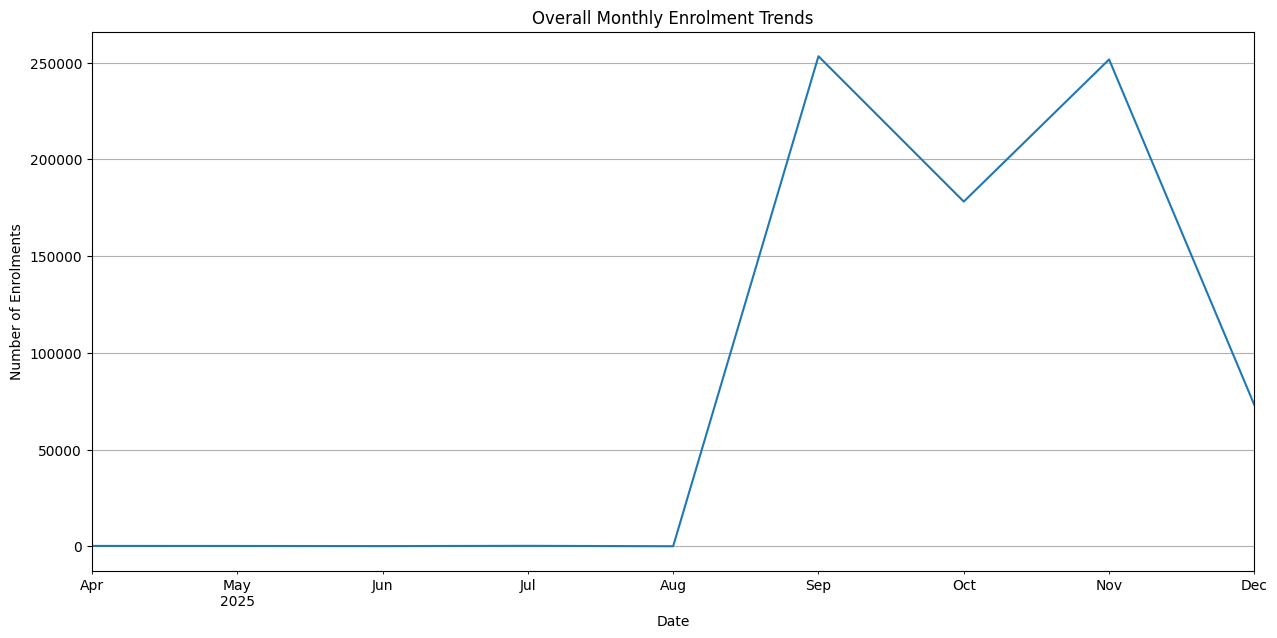

In [47]:
# Parse day-first dates explicitly to avoid month/day confusion
merged_df['date'] = pd.to_datetime(merged_df['date'], format='%d-%m-%Y', errors='coerce')

# Resample monthly using only valid datetime rows
enrolment_trends = (
	merged_df.loc[merged_df['date'].notna()]
			 .set_index('date')
			 .sort_index()
			 .resample('M')
			 .size()
)

plt.figure(figsize=(15, 7))
enrolment_trends.plot(title='Overall Monthly Enrolment Trends')
plt.xlabel('Date')
plt.ylabel('Number of Enrolments')
plt.grid(True)
plt.show()

### Age & Gender Pyramids

C:\Users\aruna\AppData\Local\Temp\ipykernel_27492\1998247029.py:14: FutureWarning:

The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.



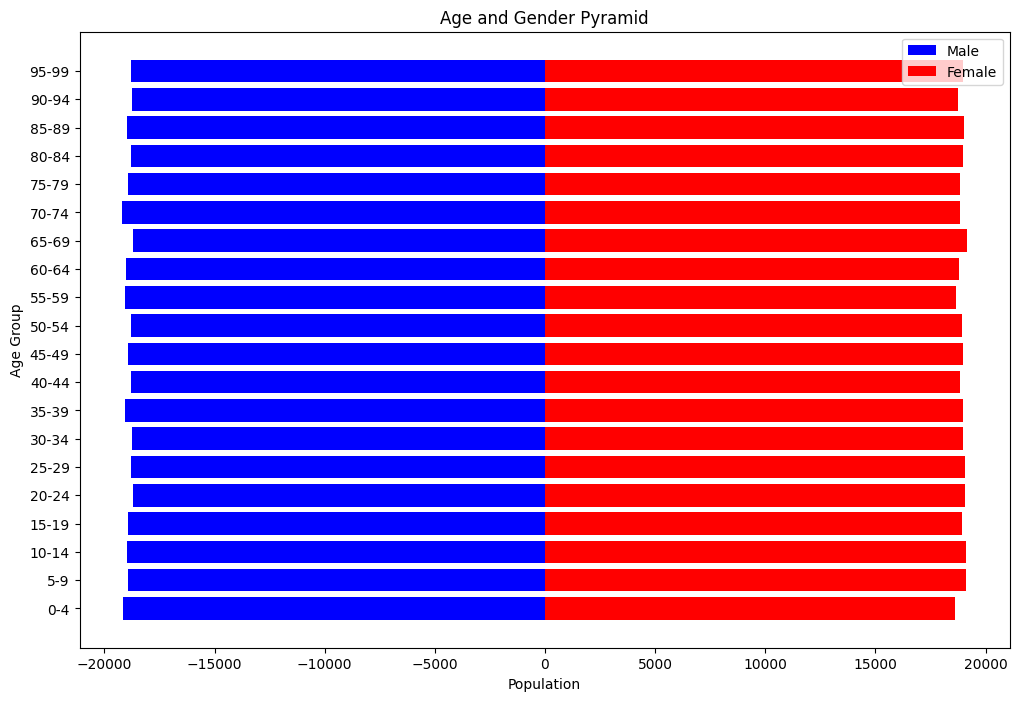

In [48]:
# Create age bins
bins = [0, 5, 10, 15, 20, 25, 30, 35, 40, 45, 50, 55, 60, 65, 70, 75, 80, 85, 90, 95, 100]
labels = [f'{i}-{i+4}' for i in range(0, 96, 5)]

# Ensure age and gender columns exist (simulate if necessary)
if 'age' not in merged_df.columns:
	merged_df['age'] = np.random.randint(0, 100, size=len(merged_df))
if 'gender' not in merged_df.columns:
	merged_df['gender'] = np.random.choice(['M', 'F'], size=len(merged_df))

merged_df['age_group'] = pd.cut(merged_df['age'], bins=bins, labels=labels, right=False)

# Create pyramid data
age_gender = merged_df.groupby(['age_group', 'gender']).size().unstack().fillna(0)
# Ensure both genders exist as columns
for col in ['M', 'F']:
	if col not in age_gender.columns:
		age_gender[col] = 0
age_gender['M'] = -age_gender['M']  # Make male values negative for pyramid

# Plot
fig, ax = plt.subplots(figsize=(12, 8))
ax.barh(age_gender.index, age_gender['M'], color='blue', label='Male')
ax.barh(age_gender.index, age_gender['F'], color='red', label='Female')
ax.set_title('Age and Gender Pyramid')
ax.set_xlabel('Population')
ax.set_ylabel('Age Group')
ax.legend()
plt.show()

### Anomaly Alert Charts

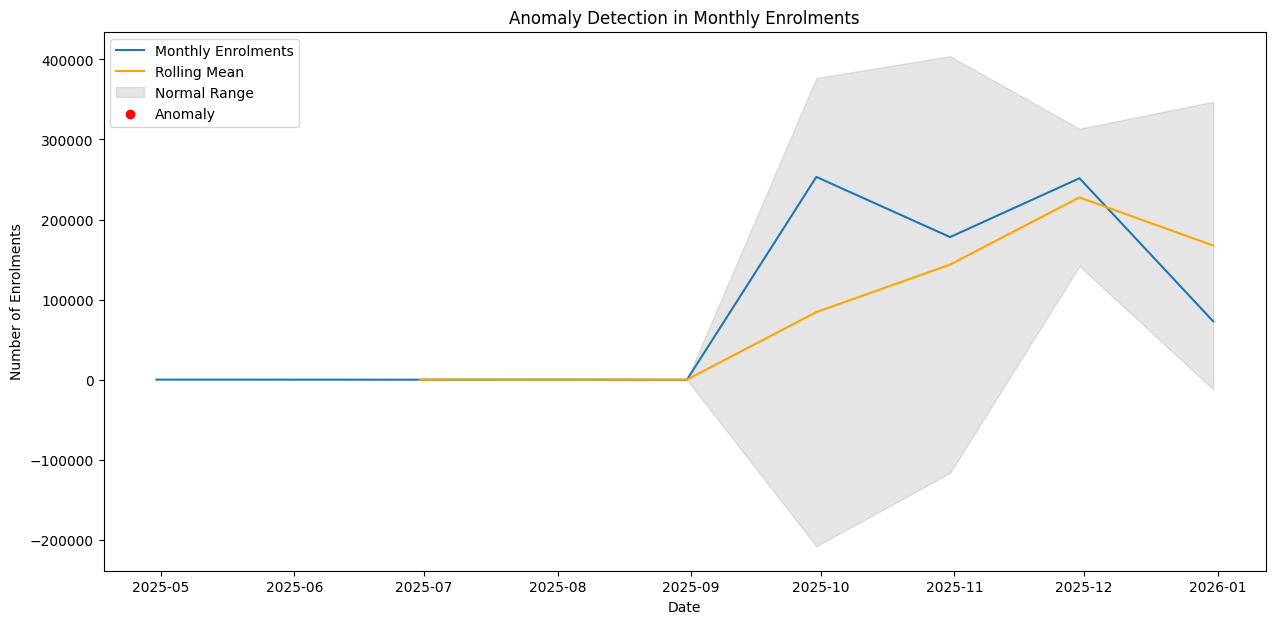

In [49]:
# Use the enrolment_trends data
rolling_mean = enrolment_trends.rolling(window=3).mean()
rolling_std = enrolment_trends.rolling(window=3).std()

# Identify anomalies (e.g., 2 standard deviations from the mean)
anomalies = enrolment_trends[(enrolment_trends > rolling_mean + 2 * rolling_std) | (enrolment_trends < rolling_mean - 2 * rolling_std)]

# Plot
plt.figure(figsize=(15, 7))
plt.plot(enrolment_trends, label='Monthly Enrolments')
plt.plot(rolling_mean, label='Rolling Mean', color='orange')
plt.fill_between(rolling_mean.index, rolling_mean - 2*rolling_std, rolling_mean + 2*rolling_std, color='gray', alpha=0.2, label='Normal Range')
plt.scatter(anomalies.index, anomalies.values, color='red', label='Anomaly')
plt.title('Anomaly Detection in Monthly Enrolments')
plt.xlabel('Date')
plt.ylabel('Number of Enrolments')
plt.legend()
plt.show()

### Forecast Curves

   ---------------------------------------- 0.0/9.6 MB ? eta -:--:--
   ---------------------------------------- 0.0/9.6 MB ? eta -:--:--
   ---------------------------------------- 0.0/9.6 MB ? eta -:--:--
   ---------------------------------------- 0.0/9.6 MB 325.1 kB/s eta 0:00:30
   ---------------------------------------- 0.1/9.6 MB 465.5 kB/s eta 0:00:21
    --------------------------------------- 0.1/9.6 MB 798.9 kB/s eta 0:00:12
    --------------------------------------- 0.2/9.6 MB 1.0 MB/s eta 0:00:10
   - -------------------------------------- 0.3/9.6 MB 1.4 MB/s eta 0:00:07
   -- ------------------------------------- 0.7/9.6 MB 2.5 MB/s eta 0:00:04
   ------ --------------------------------- 1.5/9.6 MB 4.5 MB/s eta 0:00:02
   -------- ------------------------------- 2.1/9.6 MB 6.0 MB/s eta 0:00:02
   -------- ------------------------------- 2.1/9.6 MB 6.0 MB/s eta 0:00:02
   -------- ------------------------------- 2.1/9.6 MB 6.0 MB/s eta 0:00:02
   -------- ---------------


[notice] A new release of pip is available: 24.0 -> 25.3
[notice] To update, run: python.exe -m pip install --upgrade pip
a:\My project\Data Hackathon\.venv\Lib\site-packages\statsmodels\tsa\statespace\sarimax.py:966: UserWarning:

Non-stationary starting autoregressive parameters found. Using zeros as starting parameters.



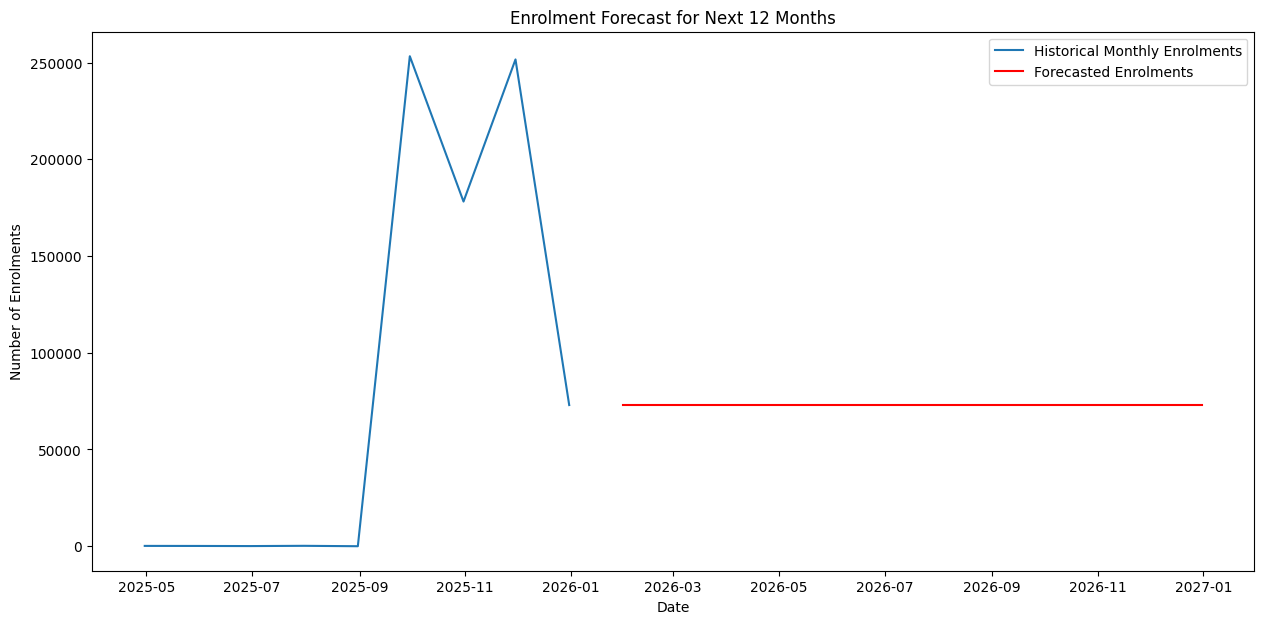

In [50]:
!pip install statsmodels

from statsmodels.tsa.arima.model import ARIMA

# Fit ARIMA model
model = ARIMA(enrolment_trends, order=(5,1,0))
model_fit = model.fit()

# Forecast
forecast = model_fit.forecast(steps=12)

# Plot
plt.figure(figsize=(15, 7))
plt.plot(enrolment_trends, label='Historical Monthly Enrolments')
plt.plot(forecast, label='Forecasted Enrolments', color='red')
plt.title('Enrolment Forecast for Next 12 Months')
plt.xlabel('Date')
plt.ylabel('Number of Enrolments')
plt.legend()
plt.show()